# Лабораторная работа №2. Временные ряды

## Обработка данных

### Получение данных из Excel

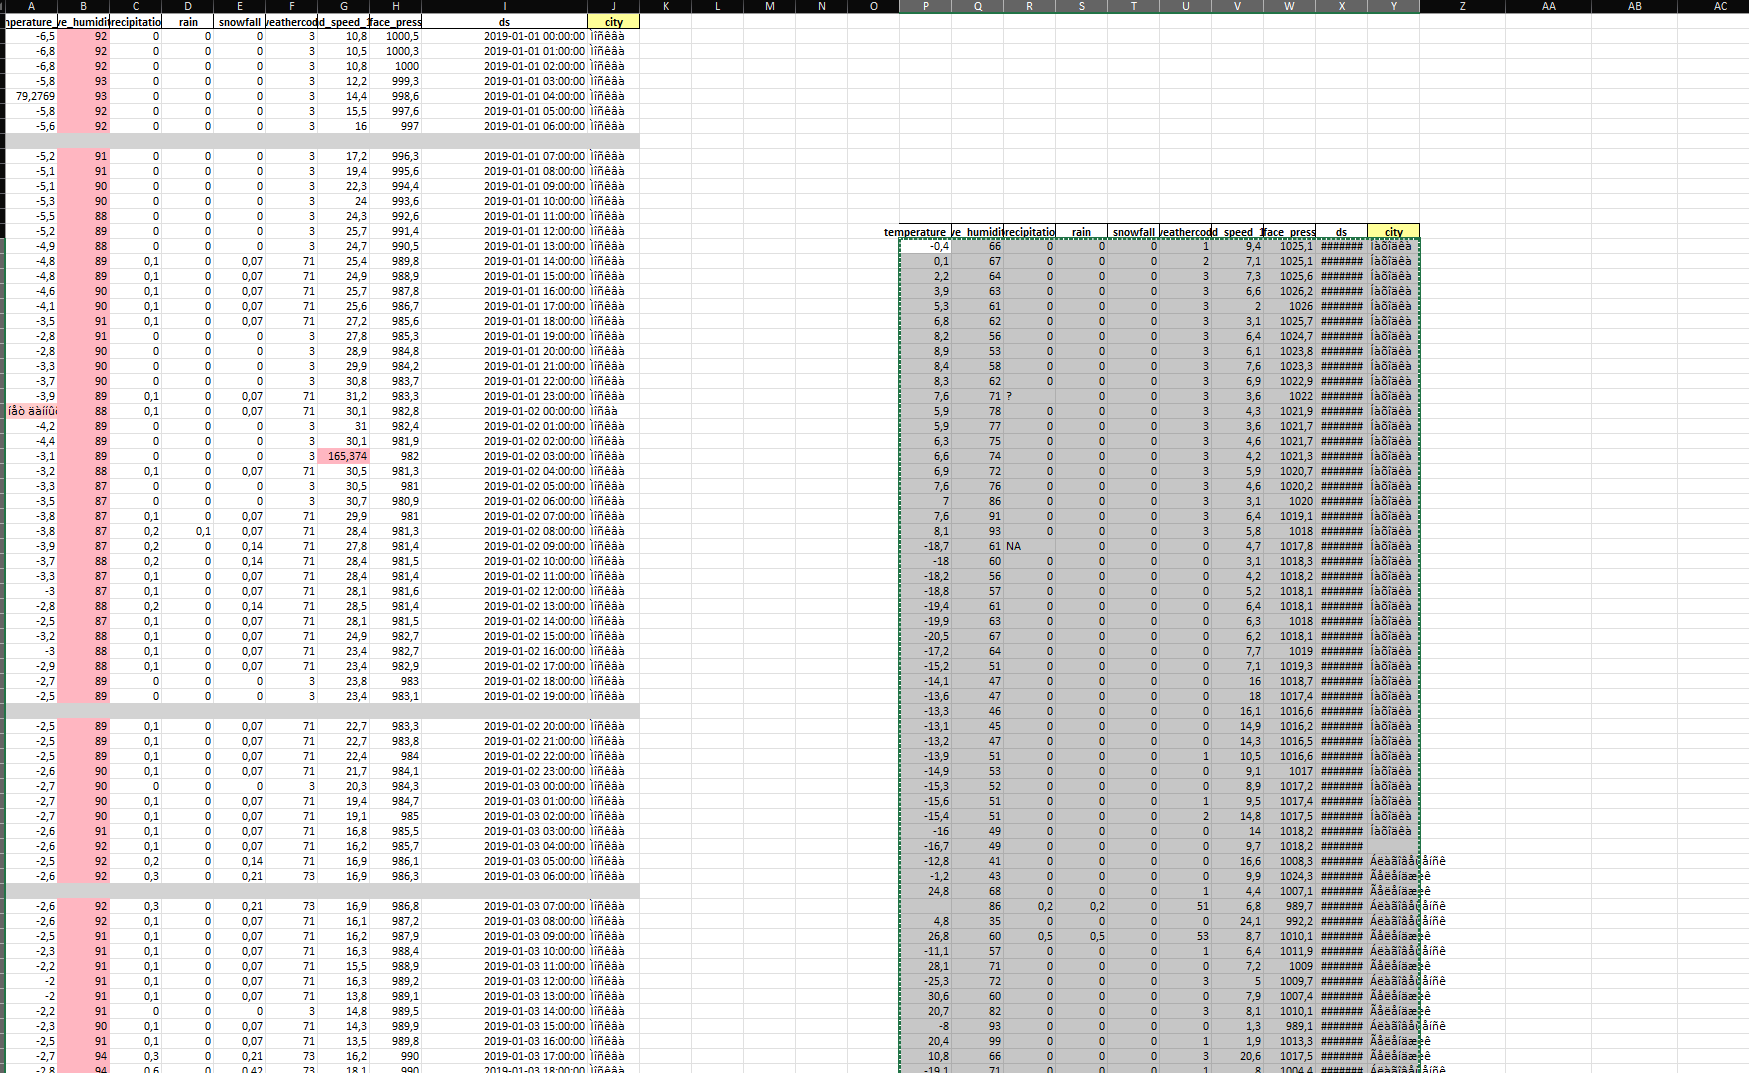

Передвинем информацию в основную таблицу

In [208]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [209]:
from pathlib import Path

import pandas as pd
from openpyxl import load_workbook

PATH = Path("/content/drive/MyDrive/have_fun.xlsx")

wb = load_workbook(PATH, read_only=True, data_only=True)
rows = []
for ws in wb.worksheets:
    rows.append(
        {
            "title": ws.title,
            "visible": ws.sheet_state == "visible",
        }
    )
wb.close()


summary = pd.DataFrame(rows)
print("Листы:")
display(summary)

parts = []

xl = pd.ExcelFile(PATH, engine="openpyxl")
for name in xl.sheet_names:
    df0 = pd.read_excel(PATH, sheet_name=name, header=None, engine="openpyxl", parse_dates=True)
    ncols = df0.shape[1]
    print(f"\n{name!r} (первые 5 строк)")
    if ncols != 0:
      parts.append(df0)
    print(df0.head(5))

df = pd.concat(parts, ignore_index=True)
print("\nИтоговый датафрейм:")
print(df.head())

Листы:


,title,visible
0,Ëèñò1,True
1,Лист1,True
2,ÌÀÈ,True
3,ýòî,True
4,ÿ,True
5,!,True
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,True
7,Ëèñò3_ñìåøàííûå_òèïû,True



'Ëèñò1' (первые 5 строк)
                0                     1              2     3         4  \
0  temperature_2m  relative_humidity_2m  precipitation  rain  snowfall   
1             3.8                    82              0     0         0   
2              -3                    70              0     0         0   
3            -1.3                    86              0     0         0   
4       19.299999                    49              0     0         0   

             5               6                 7                    8  \
0  weathercode  wind_speed_10m  surface_pressure                   ds   
1            3            19.1              1010  2020-01-31 02:00:00   
2            3              24        981.900024  2025-02-28 09:00:00   
3            2             8.8       1021.200012  2022-01-03 02:00:00   
4            0       22.799999       1016.200012  2020-09-17 06:00:00   

              9  
0          city  
1     Ãåëåíäæèê  
2  Áëàãîâåùåíñê  
3     Ãåëåíäæèê  


В данном файле Excel находится семь листов, два из них скрытые, только три из них имеют информацию. Был создан единый датафрейм, объединяющий три листа

### Очистка датафрейма

Добавим индексацию, очистим пустые колонки

In [210]:
print("Shape: ", df.shape)

hdr = df.iloc[0]
body = df.iloc[1:].reset_index(drop=True)

mask = hdr.notna() & hdr.astype(str).str.strip().ne("")
body = body.loc[:, mask.values]
body.columns = hdr[mask].astype(str).str.strip().values

df_clean = body

empty = df_clean.columns[df_clean.isna().all()].tolist()
df_clean = df_clean.drop(columns=empty)
display(df_clean)
print(df_clean.columns)

Shape:  (373139, 21)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.8,82,0,0,0,3,19.1,1010,2020-01-31 02:00:00,Ãåëåíäæèê
1,-3,70,0,0,0,3,24,981.900024,2025-02-28 09:00:00,Áëàãîâåùåíñê
2,-1.3,86,0,0,0,2,8.8,1021.200012,2022-01-03 02:00:00,Ãåëåíäæèê
3,19.299999,49,0,0,0,0,22.799999,1016.200012,2020-09-17 06:00:00,Ãåëåíäæèê
4,9.6,89,0,0,0,0,8.8,1024.400024,2025-04-16 05:00:00,Ãåëåíäæèê
...,...,...,...,...,...,...,...,...,...,...
373133,2.5,84,0.3,0.2,0.07,71,5.5,1005.099976,2025-12-31 19:00:00,Ñî÷è
373134,2.6,79,0.1,0.1,0,51,8.4,1006.099976,2025-12-31 20:00:00,Ñî÷è
373135,2.2,79,0.2,0.1,0.07,71,5.3,1006.099976,2025-12-31 21:00:00,Ñî÷è
373136,1.4,81,0,0,0,3,4.9,1007.099976,2025-12-31 22:00:00,Ñî÷è


Index(['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain',
       'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds',
       'city'],
      dtype='object')


Явно видно, что названия городов в другой кодировке. Исправим это для корректной работы

In [211]:
def decode_city(s):
    if pd.isna(s) or not isinstance(s, str):
        return s
    try:
        return s.encode('latin1').decode('cp1251')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

df_clean["city"] = df_clean["city"].map(decode_city)
print("Уникальные города после декодирования:")
print(df_clean["city"].unique())

Уникальные города после декодирования:
['Геленджик' 'Благовещенск' 'БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенскк'
 'благовещенск' 'ГЕЛЕНДЖИК' 'геленджик' 'Геленджикк' 'Геленджи' 'city'
 'Москва' nan 'Мосва' 'Находка' 'Санкт-Петербург' 'Сочи' 'Сычи' 'Счи'
 'Соч']


Теперь можно заметить, что названия городов в разном формате и с опечатками. Преобразуем

In [212]:
import numpy as np

CANON = {
    "геленджик": "Геленджик",
    "геленджикк": "Геленджик",
    "геленджи": "Геленджик",
    "благовещенск": "Благовещенск",
    "благовещенс": "Благовещенск",
    "благовещенскк": "Благовещенск",
    "москва": "Москва",
    "мосва": "Москва",
    "находка": "Находка",
    "санкт-петербург": "Санкт-Петербург",
    "сочи": "Сочи",
    "сычи": "Сочи",
    "счи": "Сочи",
    "соч": "Сочи",
}

def norm_city(city: str):
  if city is None or (isinstance(city, float) and np.isnan(city)):
    return np.nan

  s = str(city).strip()
  if s == "" or s.lower() == "city":
        return np.nan

  city_lower = city.lower()
  return CANON.get(city_lower, city)

df_clean["city"] = df_clean["city"].map(norm_city)

df_clean["city"].unique()

array(['Геленджик', 'Благовещенск', nan, 'Москва', 'Находка',
       'Санкт-Петербург', 'Сочи'], dtype=object)

Теперь города в едином формате записи. Преобразуем числовые признаки в numeric

In [213]:
df_clean["ds"] = pd.to_datetime(df_clean["ds"], errors="coerce")

num_cols = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "rain",
    "snowfall", "weathercode", "wind_speed_10m", "surface_pressure",
]
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

df_clean["city"] = df_clean["city"].astype('string')

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373138 entries, 0 to 373137
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366357 non-null  float64       
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         366976 non-null  float64       
 3   rain                  370652 non-null  float64       
 4   snowfall              370652 non-null  float64       
 5   weathercode           368810 non-null  float64       
 6   wind_speed_10m        367563 non-null  float64       
 7   surface_pressure      370651 non-null  float64       
 8   ds                    370650 non-null  datetime64[ns]
 9   city                  370648 non-null  string        
dtypes: datetime64[ns](1), float64(8), string(1)
memory usage: 28.5 MB


Параметр `errors="coerce"` заменяет на nan все то, что не получилось превратить в число, что помогает бороться с такими вот подлянками:

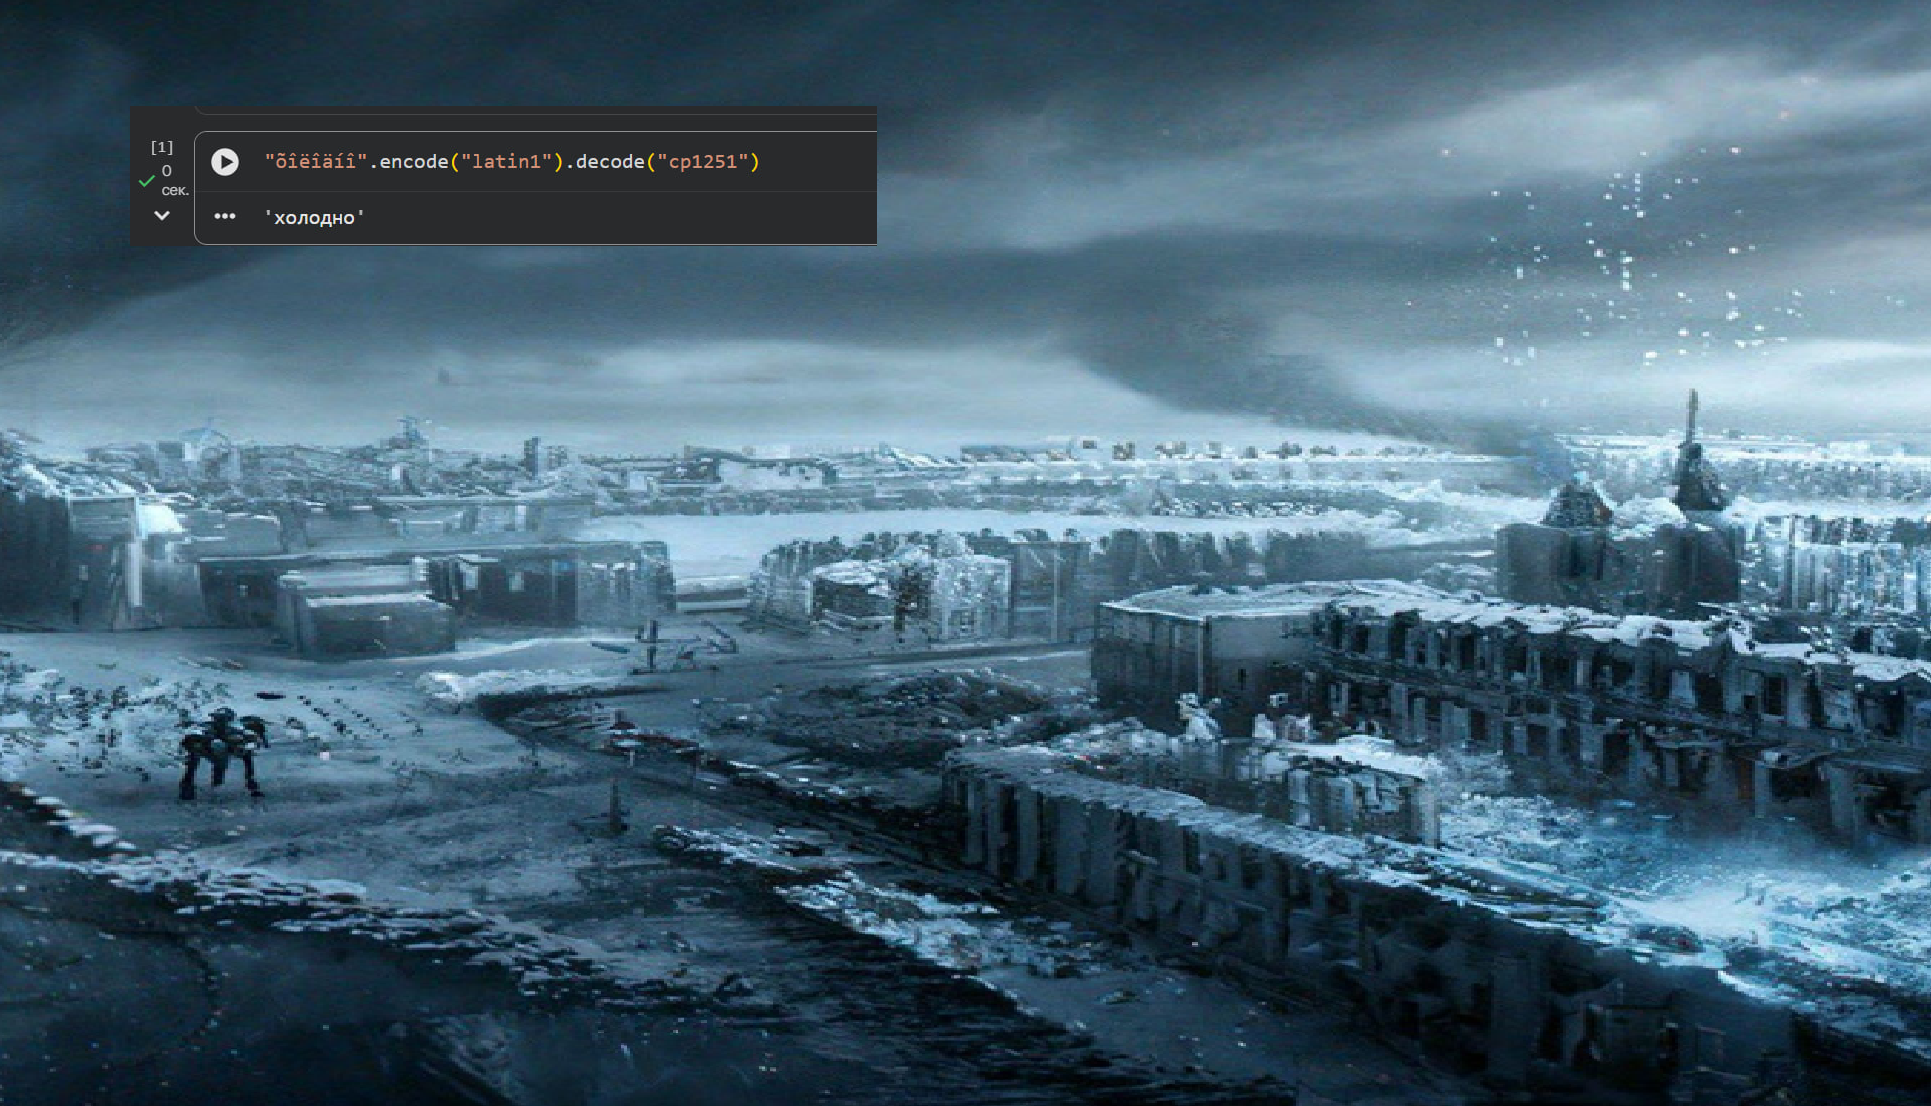

In [214]:
df_duplicated = df_clean[df_clean.duplicated()]
df_have_nan = df_clean.isna().any().any()

print(f"Всего дублей: {df_duplicated.shape}")
print(f"Есть ли NaN: {df_have_nan}")

df_clean = df_clean.drop_duplicates()
print("\nДублей после удаления:", len(df_clean[df_clean.duplicated()]))


Всего дублей: (4930, 10)
Есть ли NaN: True

Дублей после удаления: 0


Если заполнить пропуски до разделения на выборки, то произойдет утечка данных. Для визуализации будем временно дропать nan

In [215]:
df_for_plots = df_clean.dropna()

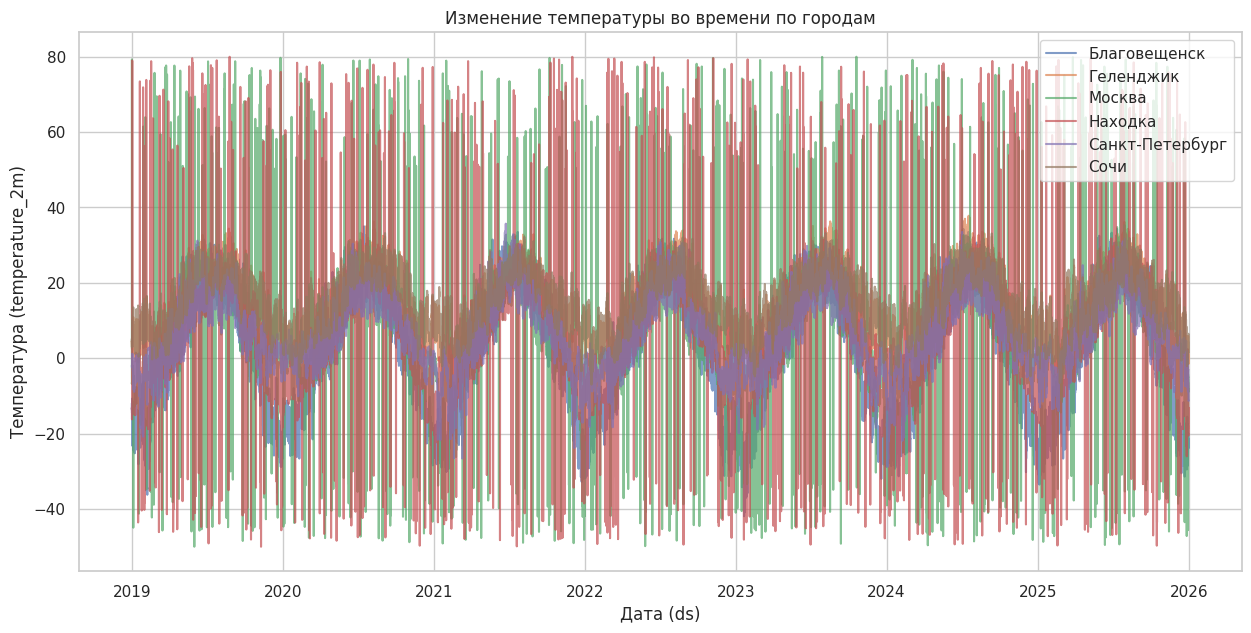

In [216]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

for city_name, group in df_for_plots.groupby('city'):
    group = group.sort_values('ds')
    plt.plot(group['ds'], group['temperature_2m'], label=city_name, alpha=0.7)

plt.title('Изменение температуры во времени по городам')
plt.xlabel('Дата (ds)')
plt.ylabel('Температура (temperature_2m)')
plt.legend()
plt.grid(True)
plt.show()

После визуального анализа явно видны выбросы. Удалим их

In [217]:
def replace_outliers_and_update(df, columns):
    df_new = df.copy()
    for col in columns:
        df_new[col] = pd.to_numeric(df_new[col], errors='coerce')

        if col == 'weathercode':
            print(f"Столбец {col}: пропущен (обработка выбросов не требуется)")
            continue

        Q1 = df_new[col].quantile(0.25)
        Q3 = df_new[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_mask = (df_new[col].notna()) & ((df_new[col] < lower_bound) | (df_new[col] > upper_bound))
        n_outliers = outliers_mask.sum()

        df_new.loc[outliers_mask, col] = np.nan
        print(f"Столбец {col}: найдено и заменено на NaN {n_outliers} выбросов")

    return df_new

df_clean_2 = replace_outliers_and_update(df_clean, num_cols)

Столбец temperature_2m: найдено и заменено на NaN 4422 выбросов
Столбец relative_humidity_2m: найдено и заменено на NaN 2423 выбросов
Столбец precipitation: найдено и заменено на NaN 63102 выбросов
Столбец rain: найдено и заменено на NaN 51420 выбросов
Столбец snowfall: найдено и заменено на NaN 14045 выбросов
Столбец weathercode: пропущен (обработка выбросов не требуется)
Столбец wind_speed_10m: найдено и заменено на NaN 8635 выбросов
Столбец surface_pressure: найдено и заменено на NaN 2200 выбросов


In [218]:
df_for_plots_2 = df_clean_2.dropna()

## Анализ данных

Для дальнейшего анализа и обучения модели нужно привести всё к единому временному индексу. Для начала посмотрим какая временная индексация во временном ряде в данный момент

In [219]:
diff_counts = {}

for city, group in df_clean_2.groupby('city'):
    diffs = group['ds'].sort_values().diff().dropna()
    diff_counts[city] = diffs.value_counts()

for city, counts in diff_counts.items():
    print(f"\nГород: {city}")
    if not counts.empty:
        for delta, count in counts.items():
            print(f"  Интервал {delta}: {count} раз")
    else:
        print(" Данные отсутствуют или недостаточно точек для расчета интервала.")


Город: Благовещенск
  Интервал 0 days 01:00:00: 61367 раз

Город: Геленджик
  Интервал 0 days 01:00:00: 61367 раз

Город: Москва
  Интервал 0 days 01:00:00: 61360 раз
  Интервал 0 days 02:00:00: 2 раз
  Интервал 0 days 03:00:00: 1 раз

Город: Находка
  Интервал 0 days 01:00:00: 61335 раз
  Интервал 1 days 07:00:00: 1 раз

Город: Санкт-Петербург
  Интервал 0 days 01:00:00: 61367 раз

Город: Сочи
  Интервал 0 days 01:00:00: 61367 раз


Теперь преобразуем к дневному интервалу. Появившиеся пропуски интерполируем

In [220]:
def resample_to_daily(group):
    group = group.set_index('ds').sort_index()
    full_range = pd.date_range(start=group.index.min(), end=group.index.max(), freq='d')
    group = group.reindex(full_range)
    group['city'] = group['city'].ffill().bfill()
    group[num_cols] = group[num_cols].interpolate(method='linear')
    return group.reset_index().rename(columns={'index': 'ds'})

df_resampled = df_clean_2.groupby('city', group_keys=False).apply(resample_to_daily)

print("Размер данных до ресемплинга:", df_clean_2.shape)
print("Размер данных после ресемплинга:", df_resampled.shape)
display(df_resampled.head())

Размер данных до ресемплинга: (368208, 10)
Размер данных после ресемплинга: (15342, 10)


/tmp/ipykernel_9965/296346380.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resampled = df_clean_2.groupby('city', group_keys=False).apply(resample_to_daily)


,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
0,2019-01-01,-13.700000,56.0,0.0,0.0,0.0,3.0,12.6,1008.700012,Благовещенск
1,2019-01-02,-21.500000,82.0,0.0,0.0,0.0,0.0,12.0,1011.200012,Благовещенск
2,2019-01-03,-19.200001,74.0,0.0,0.0,0.0,0.0,10.8,1010.599976,Благовещенск
3,2019-01-04,-19.799999,73.0,0.0,0.0,0.0,0.0,3.8,1007.599976,Благовещенск
4,2019-01-05,-23.600000,77.0,0.0,0.0,0.0,2.0,8.5,1005.500000,Благовещенск


In [221]:
print("Проверка интервалов после обработки:")
for city, group in df_resampled.groupby('city'):
    diffs = group['ds'].diff().value_counts()
    print(f"\nГород: {city}")
    print(diffs)

Проверка интервалов после обработки:

Город: Благовещенск
ds
1 days    2556
Name: count, dtype: int64

Город: Геленджик
ds
1 days    2556
Name: count, dtype: int64

Город: Москва
ds
1 days    2556
Name: count, dtype: int64

Город: Находка
ds
1 days    2556
Name: count, dtype: int64

Город: Санкт-Петербург
ds
1 days    2556
Name: count, dtype: int64

Город: Сочи
ds
1 days    2556
Name: count, dtype: int64


In [222]:
df_for_plots_3 = df_resampled.dropna()

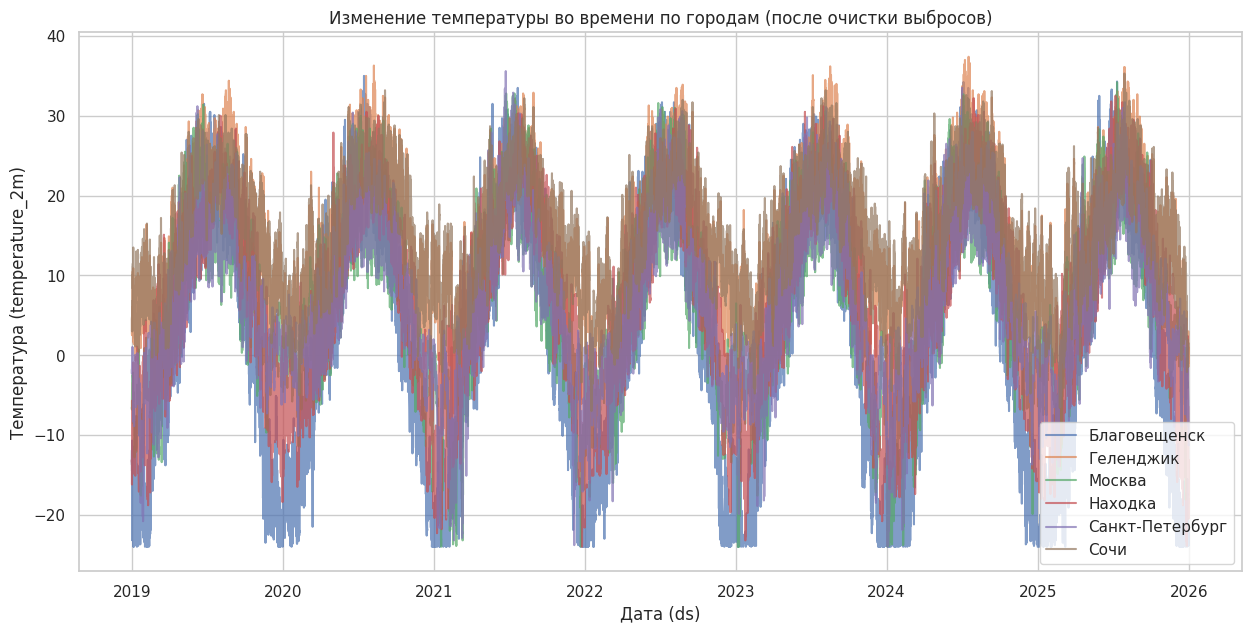

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

for city_name, group in df_for_plots_2.groupby('city'):
    group = group.sort_values('ds')
    plt.plot(group['ds'], group['temperature_2m'], label=city_name, alpha=0.7)

plt.title('Изменение температуры во времени по городам (после очистки выбросов)')
plt.xlabel('Дата (ds)')
plt.ylabel('Температура (temperature_2m)')
plt.legend()
plt.grid(True)
plt.show()

### Декомпозиция

Теперь декомпозируем ряд. Проэксперементируем с разными периодами

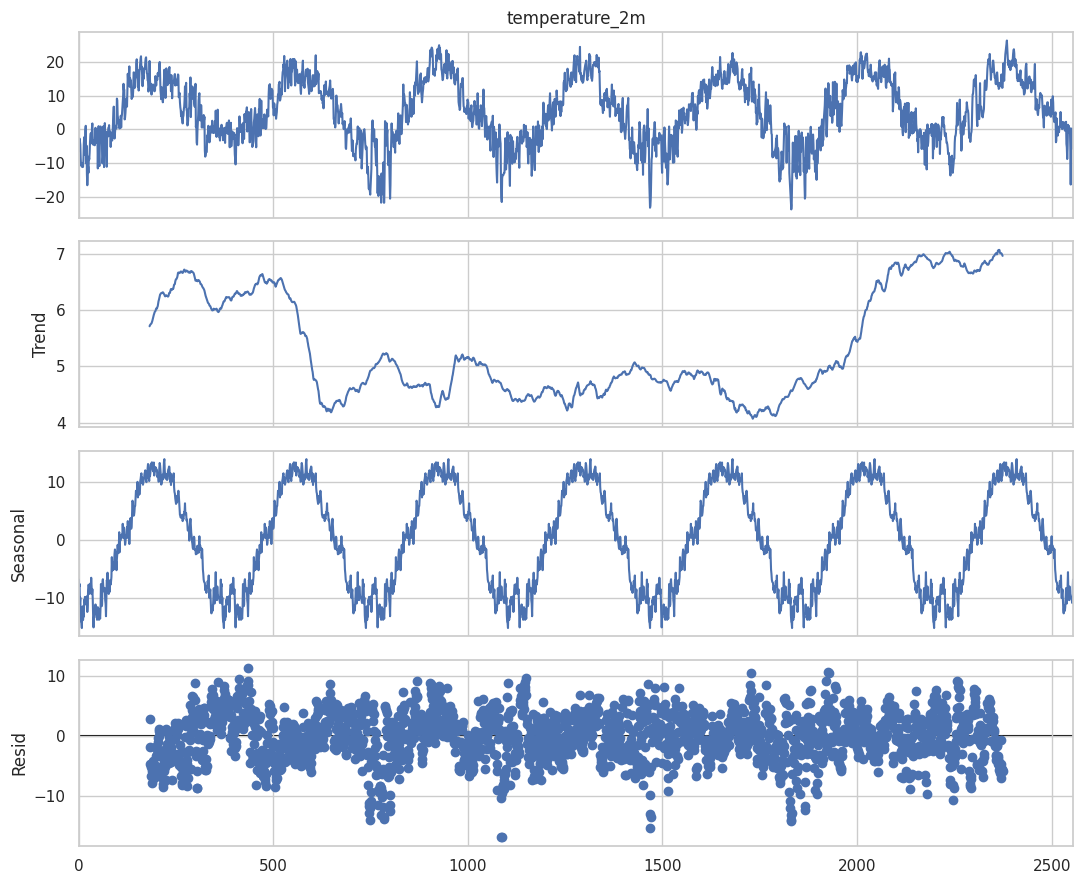

In [224]:
from statsmodels.tsa.seasonal import seasonal_decompose

from pylab import rcParams
rcParams['figure.figsize'] = 11, 9

data_to_decompose = df_for_plots_3[df_for_plots_3['city'] == 'Москва']['temperature_2m']

decompose = seasonal_decompose(data_to_decompose, period=365)
decompose.plot()

plt.show()

Годовая сезонность явно присутствует. Также есть тренд. Возможно связан с глобальным потеплением

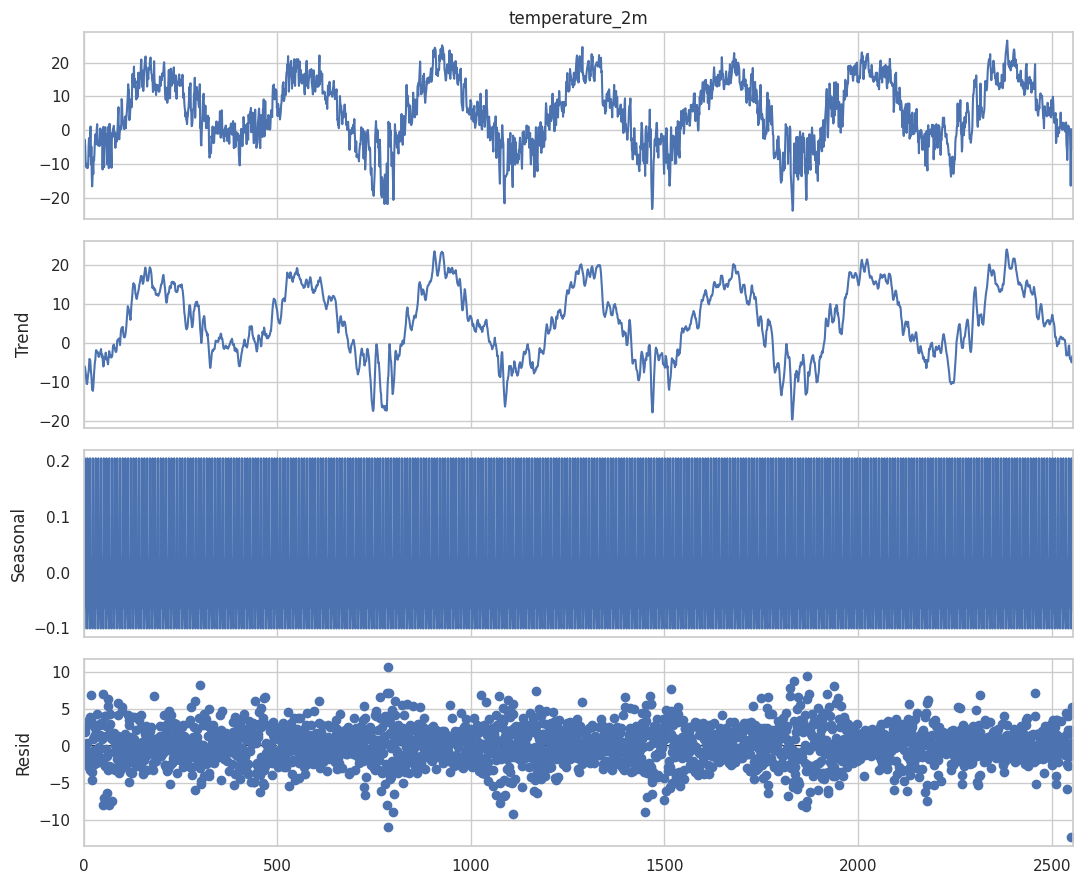

In [225]:
decompose = seasonal_decompose(data_to_decompose, period=7)
decompose.plot()

plt.show()

При периоде в 7 дней колебания сезонности крайне малы, а тренд почти повторяет основной график

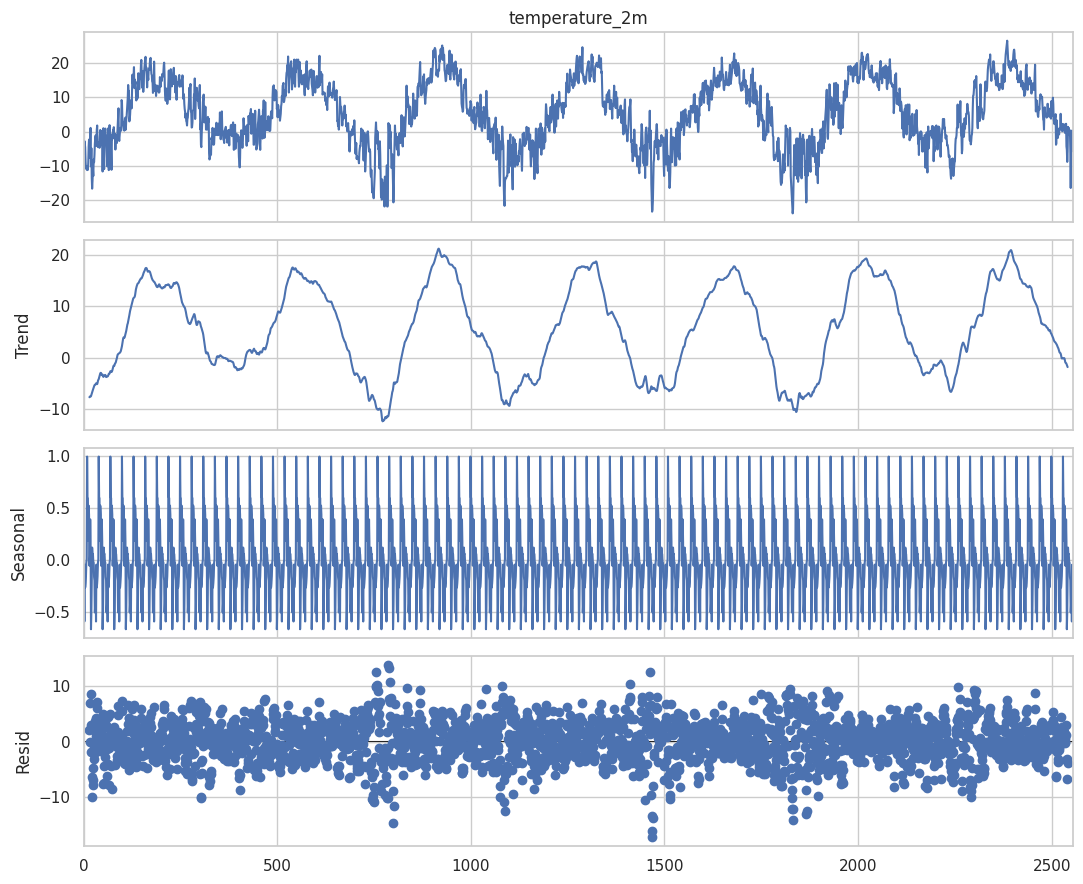

In [226]:
decompose = seasonal_decompose(data_to_decompose, period=30)
decompose.plot()

plt.show()

Колебания у сезонности стали чуть больше, но тренд все еще ведет себя почти как основной график

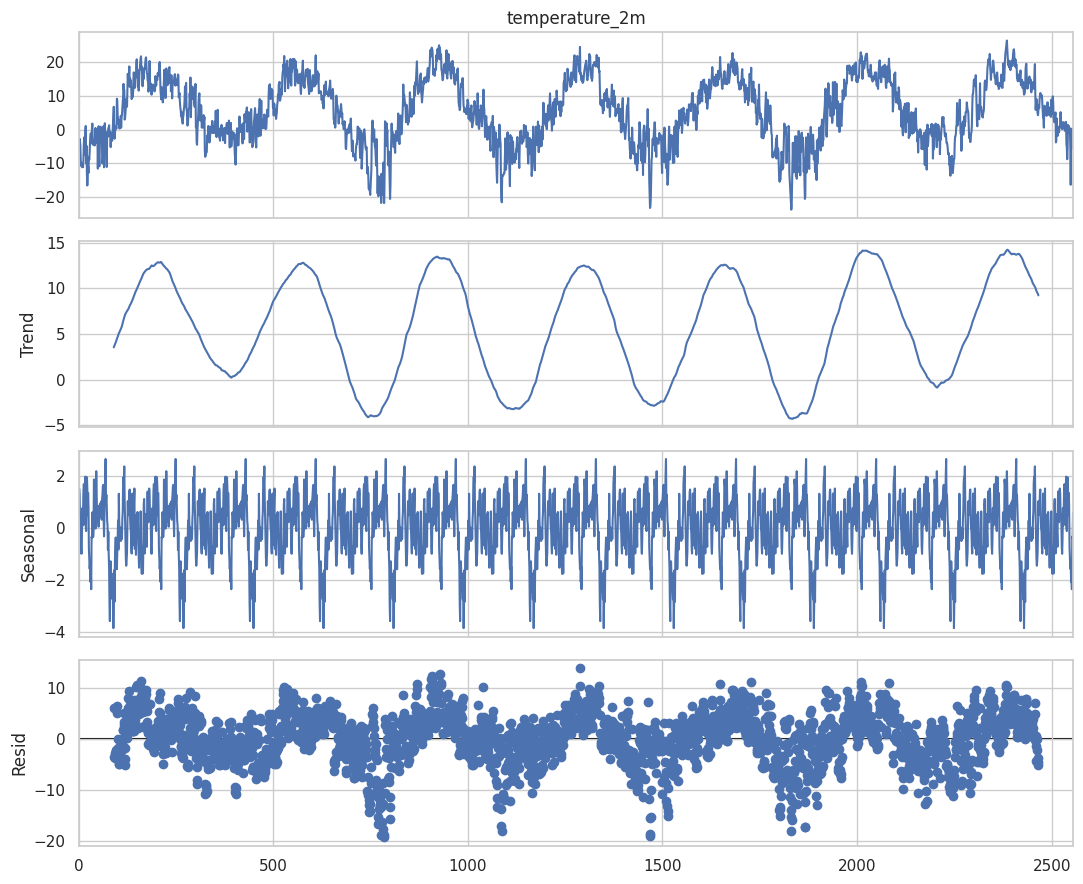

In [227]:
decompose = seasonal_decompose(data_to_decompose, period=180)
decompose.plot()

plt.show()

В графике шума появились волны, сезонность ведет себя максимально странно

Отсюда можно сделать вывод, что явно выражена только годичная сезонность

### Спектральный анализ

Построим периодограмму чтобы доказать гипотезу о годичной сезонности

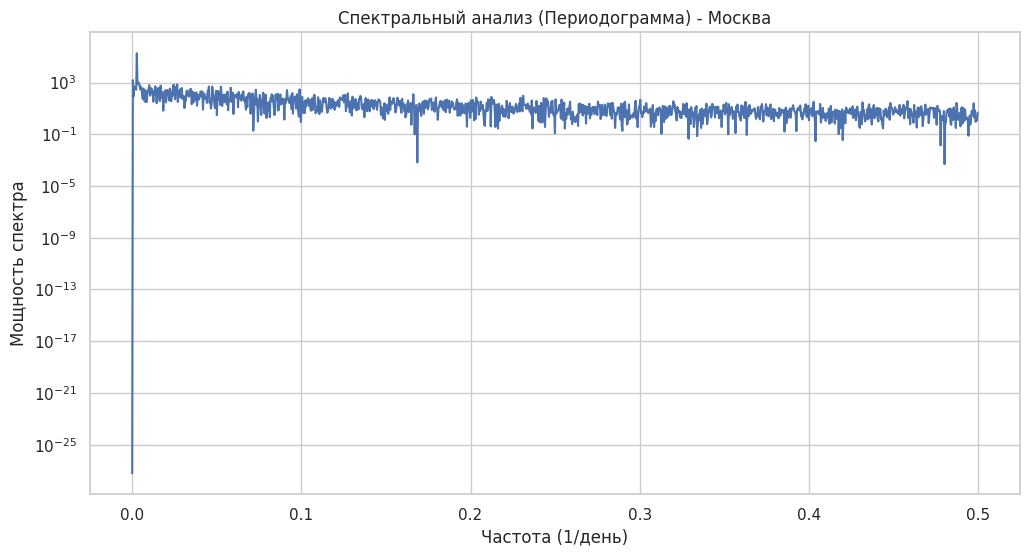

In [228]:
from scipy.signal import periodogram
import matplotlib.pyplot as plt
import numpy as np

data = df_for_plots_3[df_for_plots_3['city'] == 'Москва']['temperature_2m'].dropna()

frequencies, spectrum = periodogram(data, fs=1.0)

plt.figure(figsize=(12, 6))
plt.semilogy(frequencies, spectrum)
plt.title('Спектральный анализ (Периодограмма) - Москва')
plt.xlabel('Частота (1/день)')
plt.ylabel('Мощность спектра')
plt.grid(True)
plt.show()

Пик находится примерно у частоты 0.0027. Отсюда период примерно 365 дней, что подтверждает годичную сезонность

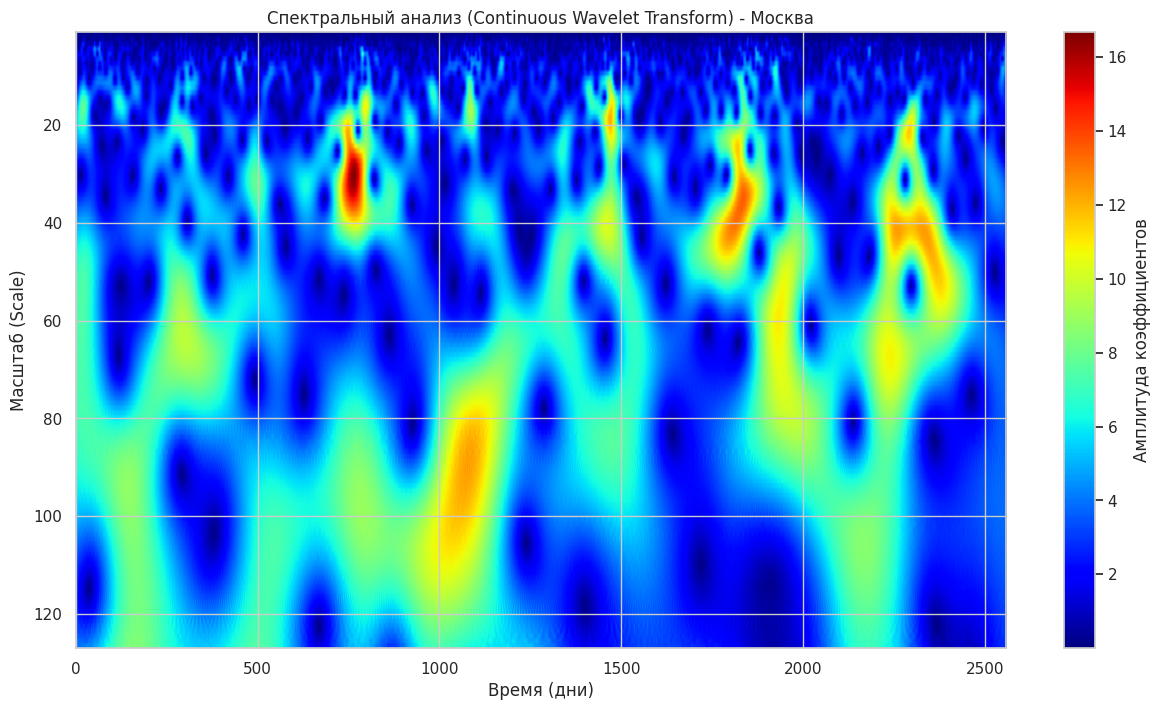

In [229]:
import pywt

data = df_for_plots_3[df_for_plots_3['city'] == 'Москва']['temperature_2m'].values
time = np.arange(len(data))

wavelet = 'cmor1.5-1.0'
scales = np.arange(1, 128)

coefficients, frequencies = pywt.cwt(data, scales, wavelet)

plt.figure(figsize=(15, 8))
plt.imshow(
    np.abs(coefficients),
    extent=[time.min(), time.max(), scales.max(), scales.min()],
    cmap='jet',
    aspect='auto'
)

plt.title('Спектральный анализ (Continuous Wavelet Transform) - Москва')
plt.ylabel('Масштаб (Scale)')
plt.xlabel('Время (дни)')
plt.colorbar(label='Амплитуда коэффициентов')
plt.show()

Всплески интенсивности в средних масштабах указывают на локальные погодные аномалии и периоды высокой волатильности. Наличие энергии в масштабах до 30–40 единиц обосновывает использование скользящих средних и лагов за 30 дней в качестве признаков

## Корреляция

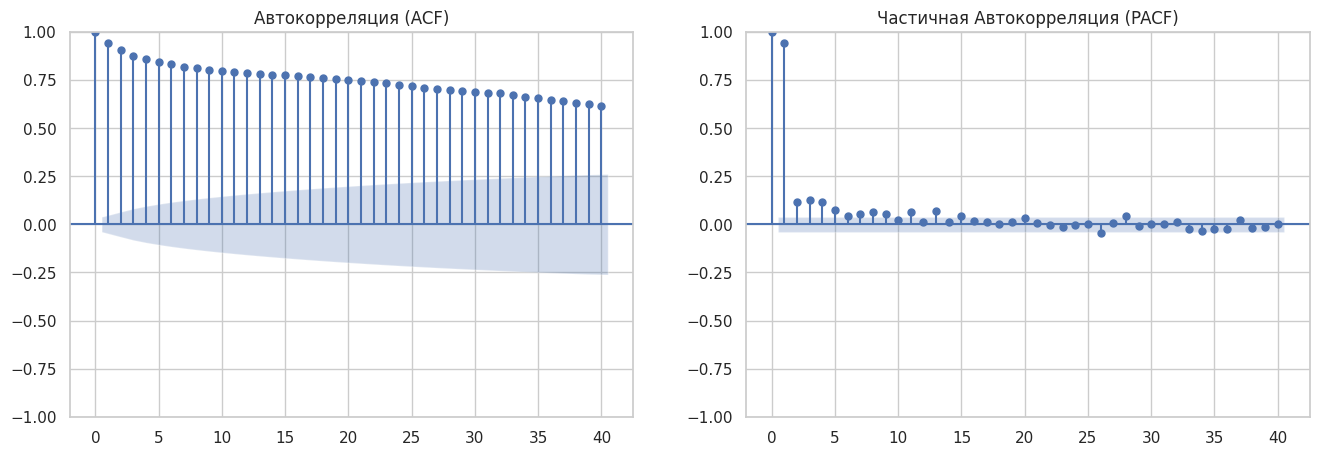

In [230]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_acf = df_for_plots_3[df_for_plots_3['city'] == 'Москва']['temperature_2m'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(data_acf, lags=40, ax=ax[0], title='Автокорреляция (ACF)')

plot_pacf(data_acf, lags=40, ax=ax[1], title='Частичная Автокорреляция (PACF)')

plt.show()

Автокорреляция показывет важность использования для прогнозов первых 3-7 лагов. Самым важным признаком является температура в прошлый день

## Подготовка к обучению

### Приведение ряда к стационарному

ds                         0
temperature_2m             0
relative_humidity_2m       0
precipitation              4
rain                       4
snowfall                   0
weathercode                0
wind_speed_10m             0
surface_pressure           0
city                       0
seasonal_diff           2190
dtype: int64


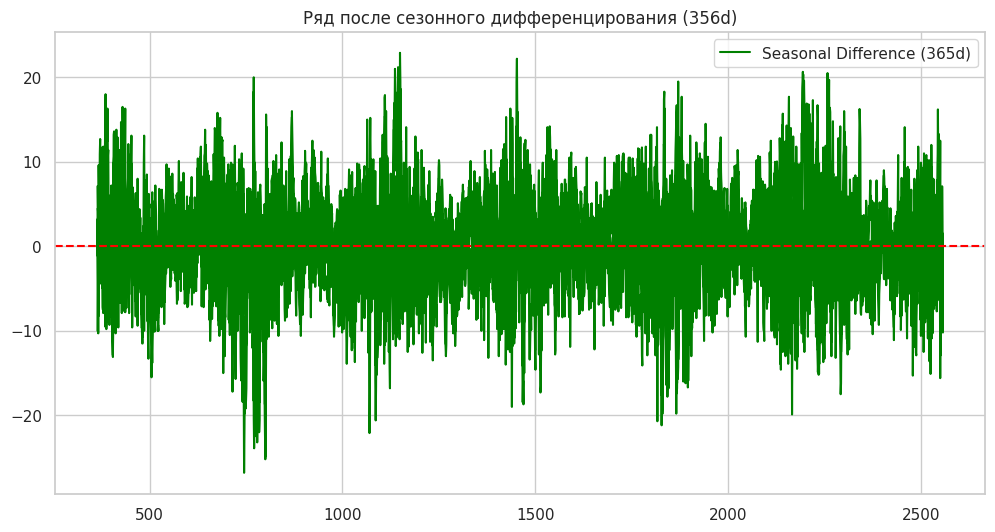

In [231]:
df_resampled['seasonal_diff'] = df_resampled.groupby('city')['temperature_2m'].transform(lambda x: x.diff(periods=365))

print(df_resampled.isna().sum())

plt.figure(figsize=(12, 6))
plt.plot(df_resampled['seasonal_diff'], color='green', label='Seasonal Difference (365d)')
plt.axhline(0, color='red', linestyle='--')
plt.title("Ряд после сезонного дифференцирования (356d)")
plt.legend()
plt.show()

In [232]:
from statsmodels.tsa.stattools import adfuller


moscow_data = df_resampled[df_resampled['city'] == 'Москва']['seasonal_diff'].dropna()
result = adfuller(moscow_data)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -13.847686023844888
p-value: 7.099416766303794e-26


Разделим на выборки до заполнения пропусков, чтобы не произошло утечки данных

### Feature engeneering

In [233]:
from sklearn.preprocessing import LabelEncoder

def create_features(df):
    data = df.copy()

    data['month'] = data['ds'].dt.month
    data['day_of_year'] = data['ds'].dt.dayofyear
    data['week_of_year'] = data['ds'].dt.isocalendar().week

    for i in range(1, 8):
        data[f'temp_lag_{i}'] = data.groupby('city')['temperature_2m'].shift(i)

    data['temp_lag_365'] = data.groupby('city')['temperature_2m'].shift(365)

    data['rolling_mean_7'] = data.groupby('city')['temperature_2m'].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )
    data['rolling_std_7'] = data.groupby('city')['temperature_2m'].transform(
        lambda x: x.shift(1).rolling(window=7).std()
    )
    data['rolling_mean_30'] = data.groupby('city')['temperature_2m'].transform(
        lambda x: x.shift(1).rolling(window=30).mean()
    )

    data['rolling_std_30'] = data.groupby('city')['temperature_2m'].transform(
        lambda x: x.shift(1).rolling(window=30).std()
    )

    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    data['temp_diff_1'] = data.groupby('city')['temperature_2m'].diff(1)

    for n in [1, 2]:
      data[f'fourier_sin_{n}'] = np.sin(2 * np.pi * n * data['ds'].dt.dayofyear / 365.25)
      data[f'fourier_cos_{n}'] = np.cos(2 * np.pi * n * data['ds'].dt.dayofyear / 365.25)

    data['trend_signal'] = data['rolling_mean_7'] - data['rolling_mean_30']

    data['dow_sin'] = np.sin(2 * np.pi * data['ds'].dt.dayofweek / 7)
    data['dow_cos'] = np.cos(2 * np.pi * data['ds'].dt.dayofweek / 7)


    return data

df_features = create_features(df_resampled)

Добавим много-много признаков со скользящим средним, а также добавим циклические признаки, чтобы показать модели сезонность, а также фурье-признаки для более глубокого анализа резких колебаний

In [234]:
def create_direct_targets(df, target_col='temperature_2m', horizon=7):
    data = df.copy()
    for i in range(1, horizon + 1):
        data[f'target_d{i}'] = data.groupby('city')[target_col].shift(-i)
    return data

df_resampled = create_direct_targets(df_features)

df_resampled = df_resampled.dropna(subset=[f'target_d{i}' for i in range(1, 8)])

### Разделение на train, val, test + интерполяция NaN

In [235]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

df_final = df_resampled.sort_values(["ds"])
max_date = df_final["ds"].max()
test_days = 30
val_days = 30

test_start = max_date - pd.Timedelta(days=test_days - 1)
val_end = test_start - pd.Timedelta(days=1)
val_start = val_end - pd.Timedelta(days=val_days - 1)

train_df = df_final[df_final["ds"] < val_start].copy()
val_df = df_final[(df_final["ds"] >= val_start) & (df_final["ds"] <= val_end)].copy()
test_df = df_final[df_final["ds"] >= test_start].copy()

def process_nans_in_split(df_split, name):
    print(f"--- Обработка NaN в выборке {name} ({len(df_split)} строк) ---")

    df_res = df_split.copy()

    cols_to_fix = [c for c in df_res.columns if c not in ['city', 'ds']]
    for col in cols_to_fix:
        df_res[col] = pd.to_numeric(df_res[col], errors='coerce')

    for col in cols_to_fix:
        df_res[col] = df_res.groupby('city', group_keys=False)[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )

    for col in cols_to_fix:
        df_res[col] = df_res.groupby('city', group_keys=False)[col].ffill()
        df_res[col] = df_res.groupby('city', group_keys=False)[col].bfill()

    print(f"Осталось NaN после обработки: {df_res.isna().sum().sum()}")
    return df_res

train_df = process_nans_in_split(train_df, "Train")
val_df = process_nans_in_split(val_df, "Validation")
test_df = process_nans_in_split(test_df, "Test")

target_cols = [c for c in df_final.columns if "target" in c]
features_columns = [c for c in df_final.columns if c not in target_cols and c not in ["ds", "city"]]

X_train = train_df[features_columns]
y_train = train_df[target_cols]

y_train_d1 = train_df["target_d1"]
y_val_d1 = val_df["target_d1"]

X_val = val_df[features_columns]
y_val = val_df[target_cols]

X_test = test_df[features_columns]
y_test = test_df[target_cols]

le = LabelEncoder()

train_df['city_encoded'] = le.fit_transform(train_df['city'])

val_df['city_encoded'] = le.transform(val_df['city'])
test_df['city_encoded'] = le.transform(test_df['city'])

features_columns.append('city_encoded')

df_features = create_features(df_resampled)

print("\nПодготовка выборок завершена. Данные чисты и разделены правильно.")

--- Обработка NaN в выборке Train (14940 строк) ---
Осталось NaN после обработки: 0
--- Обработка NaN в выборке Validation (180 строк) ---
Осталось NaN после обработки: 0
--- Обработка NaN в выборке Test (180 строк) ---
Осталось NaN после обработки: 0

Подготовка выборок завершена. Данные чисты и разделены правильно.


### Подбор параметров обучения с помощью optuna

In [236]:
pip install optuna

In [237]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

def objective(trial, model_type, X_train, y_train, X_val, y_val):
    if model_type == 'dt':
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 30),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'criterion': trial.suggest_categorical('criterion', ['squared_error', 'absolute_error'])
        }
        model = DecisionTreeRegressor(**params, random_state=42)

    elif model_type == 'rf':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
        }
        model = RandomForestRegressor(**params, n_jobs=-1, random_state=42)

    elif model_type == 'xgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        }
        model = XGBRegressor(**params, random_state=42)

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

best_params = {}


for m_type in ["dt", "rf", "xgb"]:
    study = optuna.create_study(direction="minimize")
    study.optimize(
        lambda trial: objective(trial, m_type, X_train, y_train_d1, X_val, y_val_d1),
        n_trials=25,
    )
    best_params[m_type] = study.best_params
    print(f"Лучшие параметры для {m_type}: {study.best_params}")

[I 2026-05-11 17:05:03,057] A new study created in memory with name: no-name-fb00d6a5-e665-4769-91aa-9042d1d74338
[I 2026-05-11 17:05:30,862] Trial 0 finished with value: 2.93782405934676 and parameters: {'max_depth': 19, 'min_samples_leaf': 6, 'criterion': 'absolute_error'}. Best is trial 0 with value: 2.93782405934676.
[I 2026-05-11 17:05:31,776] Trial 1 finished with value: 3.5963504401814452 and parameters: {'max_depth': 21, 'min_samples_leaf': 1, 'criterion': 'squared_error'}. Best is trial 0 with value: 2.93782405934676.
[I 2026-05-11 17:05:50,296] Trial 2 finished with value: 2.9363888786484797 and parameters: {'max_depth': 13, 'min_samples_leaf': 3, 'criterion': 'absolute_error'}. Best is trial 2 with value: 2.9363888786484797.
[I 2026-05-11 17:05:50,688] Trial 3 finished with value: 3.1547656161328934 and parameters: {'max_depth': 18, 'min_samples_leaf': 5, 'criterion': 'squared_error'}. Best is trial 2 with value: 2.9363888786484797.
[I 2026-05-11 17:05:51,010] Trial 4 finish

Лучшие параметры для dt: {'max_depth': 30, 'min_samples_leaf': 20, 'criterion': 'squared_error'}


[I 2026-05-11 17:07:36,520] Trial 0 finished with value: 2.4196796219792236 and parameters: {'n_estimators': 245, 'max_depth': 16, 'min_samples_split': 9, 'max_features': None}. Best is trial 0 with value: 2.4196796219792236.
[I 2026-05-11 17:07:42,288] Trial 1 finished with value: 2.3962303590645813 and parameters: {'n_estimators': 183, 'max_depth': 17, 'min_samples_split': 6, 'max_features': 'log2'}. Best is trial 1 with value: 2.3962303590645813.
[I 2026-05-11 17:07:42,969] Trial 2 finished with value: 2.4271668222483127 and parameters: {'n_estimators': 77, 'max_depth': 4, 'min_samples_split': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 2.3962303590645813.
[I 2026-05-11 17:07:51,270] Trial 3 finished with value: 2.392034942583855 and parameters: {'n_estimators': 227, 'max_depth': 15, 'min_samples_split': 3, 'max_features': 'log2'}. Best is trial 3 with value: 2.392034942583855.
[I 2026-05-11 17:07:56,400] Trial 4 finished with value: 2.3623611988096185 and parameters: {'

Лучшие параметры для rf: {'n_estimators': 197, 'max_depth': 13, 'min_samples_split': 10, 'max_features': 'sqrt'}


[I 2026-05-11 17:10:31,357] Trial 0 finished with value: 2.361002348922193 and parameters: {'n_estimators': 405, 'max_depth': 7, 'learning_rate': 0.011927846407983136, 'subsample': 0.8846048279489658, 'colsample_bytree': 0.6064836337012809}. Best is trial 0 with value: 2.361002348922193.
[I 2026-05-11 17:10:32,322] Trial 1 finished with value: 2.4963497741665277 and parameters: {'n_estimators': 677, 'max_depth': 3, 'learning_rate': 0.238062614419004, 'subsample': 0.8833282615686044, 'colsample_bytree': 0.5155366740189462}. Best is trial 0 with value: 2.361002348922193.
[I 2026-05-11 17:10:44,467] Trial 2 finished with value: 2.3591645000709427 and parameters: {'n_estimators': 820, 'max_depth': 8, 'learning_rate': 0.021972477381738065, 'subsample': 0.8305458145469676, 'colsample_bytree': 0.7328656550990764}. Best is trial 2 with value: 2.3591645000709427.
[I 2026-05-11 17:10:45,582] Trial 3 finished with value: 2.3752966455701325 and parameters: {'n_estimators': 686, 'max_depth': 3, 'le

Лучшие параметры для xgb: {'n_estimators': 392, 'max_depth': 6, 'learning_rate': 0.016230596513116556, 'subsample': 0.9050828747730422, 'colsample_bytree': 0.9945284860689995}


## Обучение

## Direct (прямая) стратегия

Заключается в создании модели для каждого горизонта (1-7)

In [238]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

models_direct = {m: {} for m in ['dt', 'rf', 'xgb']}
results_list = []

for m_type in ['dt', 'rf', 'xgb']:
    print(f"Обучение Direct Strategy для {m_type}")

    for day in range(1, 8):
        target = f'target_d{day}'

        if m_type == 'dt':
            model = DecisionTreeRegressor(**best_params['dt'], random_state=42)
        elif m_type == 'rf':
            model = RandomForestRegressor(**best_params['rf'], random_state=42, n_jobs=-1)
        elif m_type == 'xgb':
            model = XGBRegressor(**best_params['xgb'], random_state=42)

        model.fit(X_train, train_df[target])
        models_direct[m_type][day] = model

        preds = model.predict(X_test)
        mae = mean_absolute_error(test_df[target], preds)

        results_list.append({
            'Model': m_type,
            'Strategy': 'Direct',
            'Day': day,
            'MAE': mae
        })
    print(f"  Завершено для {m_type}")

Обучение Direct Strategy для dt
  Завершено для dt
Обучение Direct Strategy для rf
  Завершено для rf
Обучение Direct Strategy для xgb
  Завершено для xgb


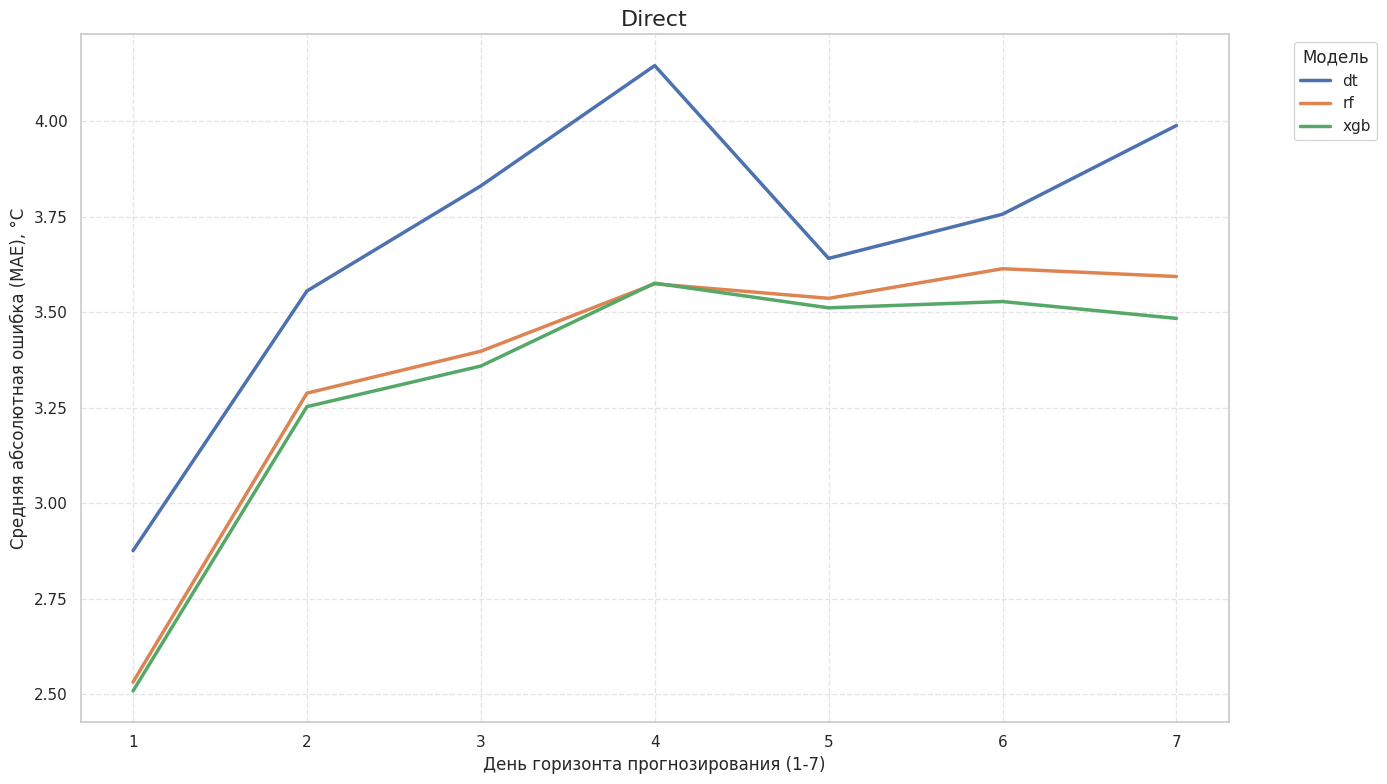

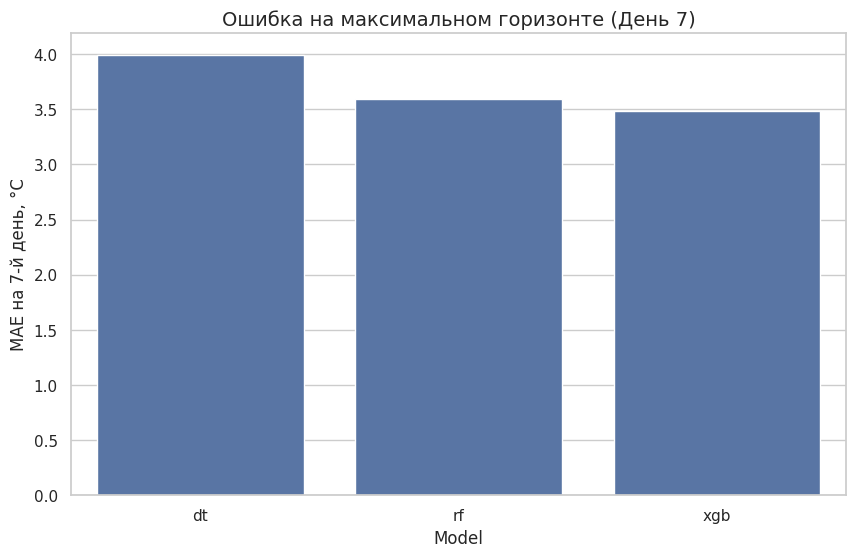

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt

df_direct = pd.DataFrame(results_list)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

ax = sns.lineplot(
    data=df_direct,
    x='Day',
    y='MAE',
    hue='Model',
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=8
)

plt.title('Direct', fontsize=16)
plt.xlabel('День горизонта прогнозирования (1-7)', fontsize=12)
plt.ylabel('Средняя абсолютная ошибка (MAE), °C', fontsize=12)
plt.xticks(range(1, 8))
plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
df_day7 = df_direct[df_direct['Day'] == 7]
sns.barplot(data=df_day7, x='Model', y='MAE')

plt.title('Ошибка на максимальном горизонте (День 7)', fontsize=14)
plt.ylabel('MAE на 7-й день, °C')
plt.show()

In [240]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    da = np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        'MAE': mae,
        'MAPE (%)': mape,
        'WAPE (%)': wape,
        'Dir_Accuracy (%)': da,
        'R2': r2
    }

all_metrics = []

for m_type in ['dt', 'rf', 'xgb']:
    for day in range(1, 8):
        target_col = f'target_d{day}'
        model = models_direct[m_type][day]

        y_true = test_df[target_col].values
        y_pred = model.predict(X_test)

        m = calculate_metrics(y_true, y_pred)
        m['Day'] = day
        m['Model'] = m_type.upper()
        all_metrics.append(m)

df_all_metrics = pd.DataFrame(all_metrics)

print("Сводные метрики по всем моделям (Direct Strategy):")
pivot_metrics = df_all_metrics.pivot_table(
    index=['Model', 'Day'],
    values=['MAE', 'WAPE (%)', 'Dir_Accuracy (%)', 'R2']
).reindex(['MAE', 'WAPE (%)', 'Dir_Accuracy (%)', 'R2'], axis=1)

display(pivot_metrics.round(3))

Сводные метрики по всем моделям (Direct Strategy):


MAE  WAPE (%)  Dir_Accuracy (%)     R2
Model Day                                          
DT    1    2.876    37.386            86.034  0.845
      2    3.556    45.733            88.268  0.762
      3    3.831    49.165            85.475  0.753
      4    4.146    53.108            86.034  0.737
      5    3.641    46.860            87.151  0.768
      6    3.757    48.022            83.240  0.769
      7    3.989    50.825            84.916  0.738
RF    1    2.532    32.911            91.061  0.883
      2    3.288    42.291            89.944  0.815
      3    3.398    43.608            88.827  0.813
      4    3.575    45.788            89.944  0.800
      5    3.537    45.515            91.620  0.801
      6    3.614    46.197            89.385  0.799
      7    3.594    45.787            92.737  0.794
XGB   1    2.508    32.608            90.503  0.882
      2    3.253    41.837            89.385  0.814
      3    3.359    43.110            88.268  0.810
      4    3.576    45.810            89.385  0.791
      5    3.512    45.194            89.944  0.798
      6    3.528    45.098            89.385  0.796
      7    3.484    44.390            89.385  0.794

### Вывод

- Общая тенденция - деградация точности при увеличении горизонта
- Лучше всего справился бустинг. Он менее чувствителен к шуму и лучше находит более сложные зависимости
- Random Forest идет вторым номером. На первых днях он почти не уступает бустингу, но к 7-му дню разрыв увеличивается. Это показывает, что бустинг точнее настраивается на долгосрочные закономерности
- Decision Tree на последнем месте. У него самый высокий темп роста ошибки. Деревья склонны к переобучению и к запоминанию лишних шумов
- Для прогноза погоды это достойный результат, учитывая, что мы используем только исторические данные без профессиональных метеорологических карт давления и фронтов

### Recursive (рекурсивная) стратегия

В отличии от прямой стратегии, в рекурсивной мы обучаем модель на один горизонт вперед и берем ее предсказания как новую правду

In [241]:
def update_features_recursive(row, prediction, feature_cols):
    new_row = row.copy()

    for i in range(7, 1, -1):
        if f'temp_lag_{i}' in new_row:
            new_row[f'temp_lag_{i}'] = new_row[f'temp_lag_{i-1}']

    if 'temp_lag_1' in new_row:
        new_row['temp_lag_1'] = prediction

    lag_cols = [f'temp_lag_{i}' for i in range(1, 8) if f'temp_lag_{i}' in new_row]
    if 'rolling_mean_7' in new_row:
        new_row['rolling_mean_7'] = np.mean([new_row[c] for c in lag_cols])

    if 'temp_diff_1' in new_row:
        new_row['temp_diff_1'] = prediction - new_row['temp_lag_2']

    return new_row

In [242]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tqdm import tqdm

models_factory = {
    'dt': lambda: DecisionTreeRegressor(**best_params['dt'], random_state=42),
    'rf': lambda: RandomForestRegressor(**best_params['rf'], random_state=42, n_jobs=-1),
    'xgb': lambda: XGBRegressor(**best_params['xgb'], random_state=42)
}

recursive_results = []

for name, factory in models_factory.items():
    print(f"Запуск рекурсии для {name.upper()}")

    model = factory()
    model.fit(X_train, y_train['target_d1'])

    test_sample = X_test.copy()
    preds_horizon = np.zeros((len(test_sample), 7))

    for i in tqdm(range(len(test_sample))):
        current_row = test_sample.iloc[i].copy()

        for day in range(7):
            row_df = pd.DataFrame([current_row])
            p = model.predict(row_df)[0]

            preds_horizon[i, day] = p

            if day < 6:
                current_row = update_features_recursive(current_row, p, features_columns)

    for day in range(1, 8):
        y_true = y_test[f'target_d{day}'].iloc[:len(test_sample)]
        mae = mean_absolute_error(y_true, preds_horizon[:, day-1])

        recursive_results.append({
            'Model': name,
            'Strategy': 'Recursive',
            'Day': day,
            'MAE': mae
        })

df_recursive = pd.DataFrame(recursive_results)

Запуск рекурсии для DT


100%|██████████| 180/180 [00:01<00:00, 97.02it/s]


Запуск рекурсии для RF


100%|██████████| 180/180 [01:09<00:00,  2.60it/s]


Запуск рекурсии для XGB


100%|██████████| 180/180 [00:06<00:00, 29.46it/s]


In [243]:
recursive_metrics = []

for name, factory in models_factory.items():
    model = models_direct[name][1]
    test_sample = X_test.copy()
    preds_horizon = np.zeros((len(test_sample), 7))

    for i in range(len(test_sample)):
        current_row = test_sample.iloc[i].copy()
        for day in range(7):
            row_df = pd.DataFrame([current_row])
            p = model.predict(row_df)[0]
            preds_horizon[i, day] = p
            if day < 6:
                current_row = update_features_recursive(current_row, p, features_columns)

    for day in range(1, 8):
        y_true = y_test[f'target_d{day}'].values
        y_pred = preds_horizon[:, day-1]

        m = calculate_metrics(y_true, y_pred)
        m['Day'] = day
        m['Model'] = name.upper()
        m['Strategy'] = 'Recursive'
        recursive_metrics.append(m)

df_recursive_metrics = pd.DataFrame(recursive_metrics)

print("Сводные метрики для Recursive Strategy:")
pivot_recursive = df_recursive_metrics.pivot_table(
    index=['Model', 'Day'],
    values=['MAE', 'WAPE (%)', 'Dir_Accuracy (%)', 'R2']
).reindex(['MAE', 'WAPE (%)', 'Dir_Accuracy (%)', 'R2'], axis=1)

display(pivot_recursive.round(3))

Сводные метрики для Recursive Strategy:


MAE  WAPE (%)  Dir_Accuracy (%)     R2
Model Day                                          
DT    1    2.876    37.386            86.034  0.845
      2    3.613    46.465            86.592  0.754
      3    3.764    48.305            86.592  0.752
      4    4.041    51.757            88.268  0.732
      5    4.151    53.415            91.620  0.713
      6    4.080    52.148            89.944  0.713
      7    4.233    53.923            84.358  0.679
RF    1    2.532    32.911            91.061  0.883
      2    3.302    42.468            89.944  0.805
      3    3.522    45.196            88.827  0.781
      4    3.842    49.213            88.827  0.756
      5    3.850    49.552            91.620  0.753
      6    3.840    49.079            89.385  0.743
      7    3.910    49.811            88.268  0.717
XGB   1    2.508    32.608            90.503  0.882
      2    3.424    44.031            88.827  0.785
      3    3.567    45.769            89.944  0.765
      4    3.907    50.041            89.385  0.744
      5    4.008    51.576            91.620  0.727
      6    3.937    50.317            89.385  0.721
      7    4.058    51.699            88.268  0.693

### Сравнение эволюции остатков: Direct vs Recursive

На 1-й день остатки одинаковы. Посмотрим на распределение ошибок на 7-й день

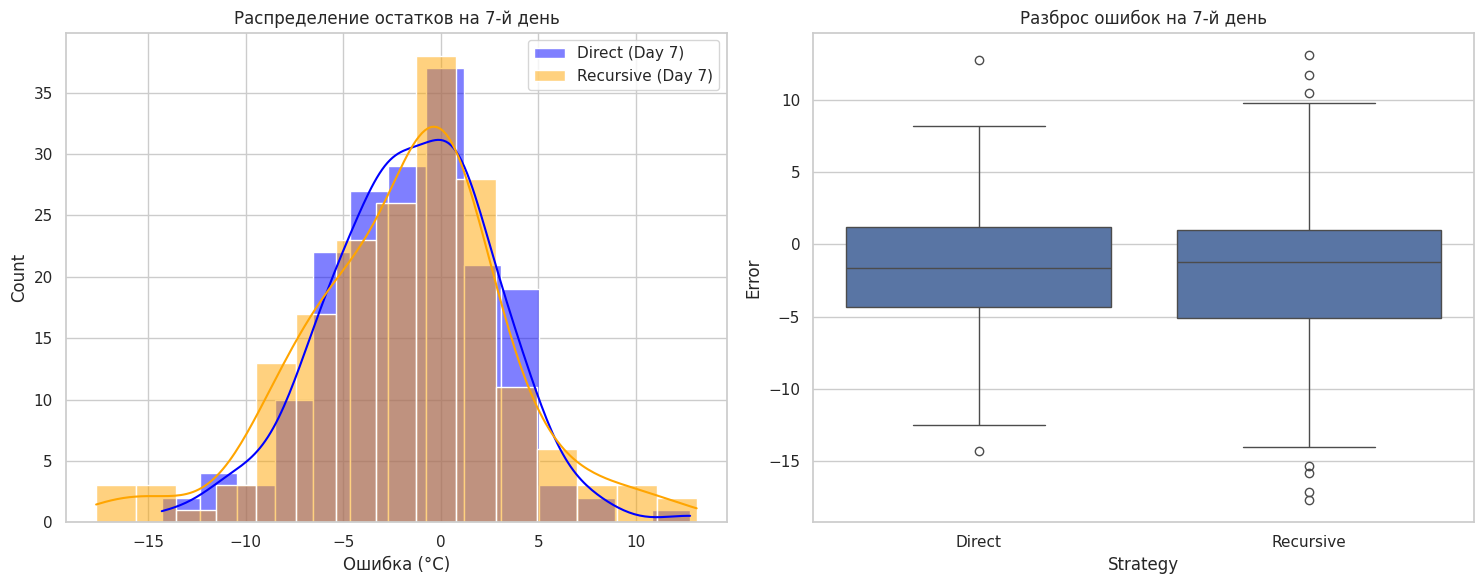

Direct (Day 7) - Mean: -1.52, Std: 4.22
Recursive (Day 7) - Mean: -1.81, Std: 5.17


In [248]:
import scipy.stats as stats

day_idx = 6

best_xgb_d7 = models_direct['xgb'][7]
y_pred_dir_d7 = best_xgb_d7.predict(X_test)
y_true_d7 = y_test['target_d7'].values
res_dir_d7 = y_true_d7 - y_pred_dir_d7

y_pred_rec_d7 = preds_horizon[:, day_idx]
res_rec_d7 = y_true_d7 - y_pred_rec_d7

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(res_dir_d7, kde=True, color='blue', label='Direct (Day 7)', alpha=0.5)
sns.histplot(res_rec_d7, kde=True, color='orange', label='Recursive (Day 7)', alpha=0.5)
plt.title('Распределение остатков на 7-й день')
plt.xlabel('Ошибка (°C)')
plt.legend()

plt.subplot(1, 2, 2)
res_df = pd.DataFrame({
    'Error': np.concatenate([res_dir_d7, res_rec_d7]),
    'Strategy': ['Direct']*len(res_dir_d7) + ['Recursive']*len(res_rec_d7)
})
sns.boxplot(data=res_df, x='Strategy', y='Error')
plt.title('Разброс ошибок на 7-й день')

plt.tight_layout()
plt.show()

print(f"Direct (Day 7) - Mean: {np.mean(res_dir_d7):.2f}, Std: {np.std(res_dir_d7):.2f}")
print(f"Recursive (Day 7) - Mean: {np.mean(res_rec_d7):.2f}, Std: {np.std(res_rec_d7):.2f}")

У рекурсии в среднем разброс ошибок больше, чем у прямого подхода. Обе модели любят занижать предсказания. Возможно вызвано тем, что модель не уловила тренд на глобальное потепление

### Итоговое сравнение стратегий

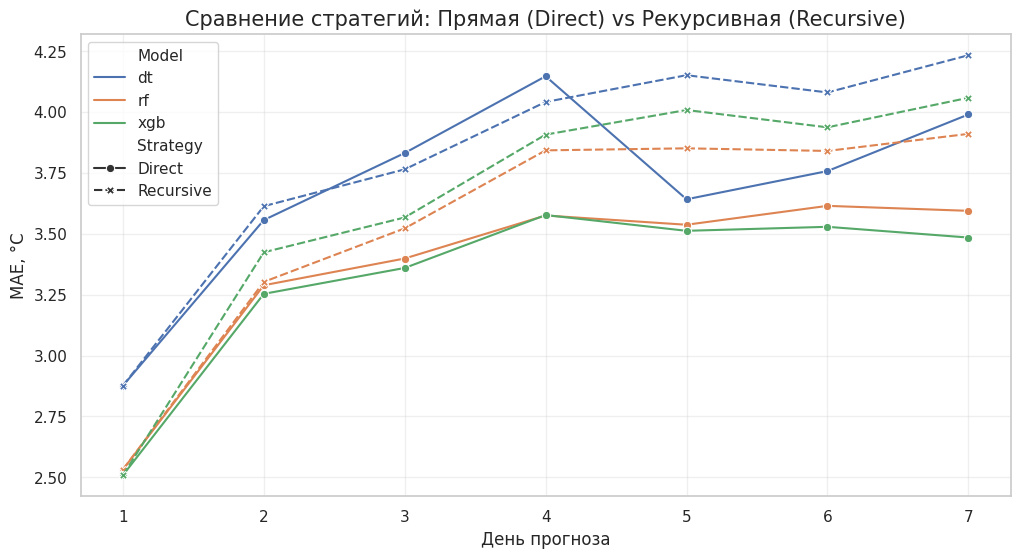

In [244]:
import seaborn as sns
import matplotlib.pyplot as plt

df_compare = pd.concat([df_direct, df_recursive], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_compare, x='Day', y='MAE', hue='Model', style='Strategy', markers=True)
plt.title('Сравнение стратегий: Прямая (Direct) vs Рекурсивная (Recursive)', fontsize=15)
plt.ylabel('MAE, °C')
plt.xlabel('День прогноза')
plt.grid(True, alpha=0.3)
plt.show()

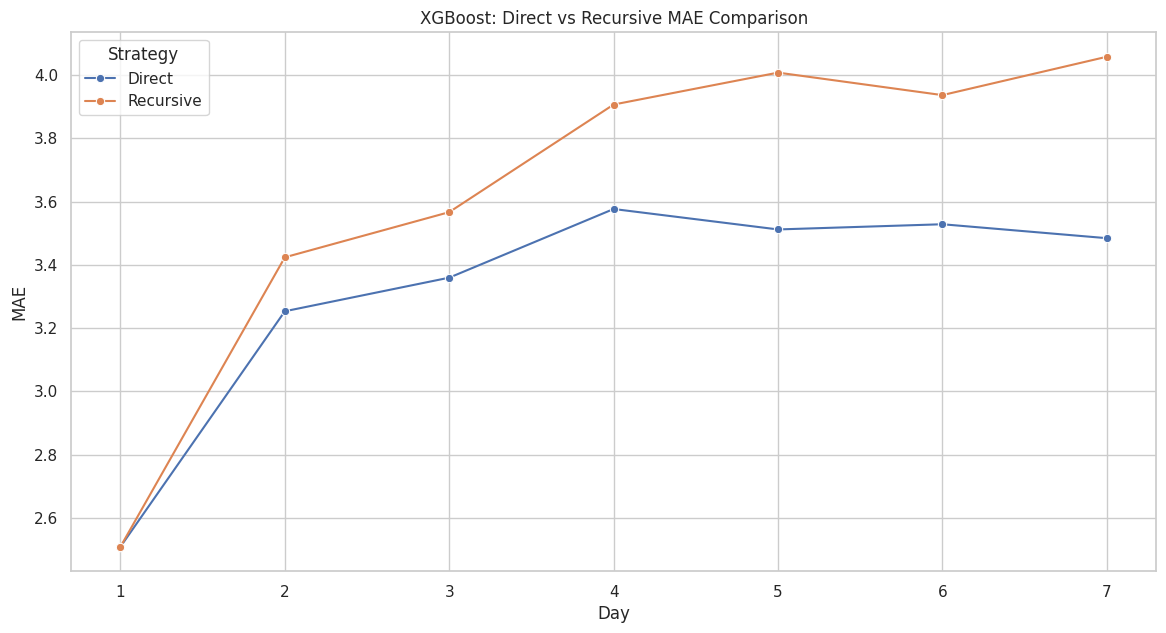

In [245]:
df_all_total = pd.concat([
    df_all_metrics.assign(Strategy='Direct'),
    df_recursive_metrics
])

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_all_total[df_all_total['Model']=='XGB'], x='Day', y='MAE', hue='Strategy', marker='o')
plt.title('XGBoost: Direct vs Recursive MAE Comparison')
plt.grid(True)
plt.show()

### Вывод

- На графике с пунктирными линиями видно, как ошибка растет быстрее. Если модель чуть-чуть ошиблась в первый день, во второй день эта ошибка становится входным параметром, и модель ошибается еще сильнее. К 7-му дню это превращается в снежный ком
- Дерево решений деградирует еще сильнее, поглощая свои же ошибки, так как более чувствительно к шуму из всех остальных моделей

## Прямой VS Рекурсивный подход

**Прямой подход**:
- Здесь учатся семь 7 независимых моделей. Каждая пытается сама найти какие-то зацепки, независимо от результатов работы своих собратьев
- Показывает хорошие результаты, ошибки на более высоких горизонтах не зависят от предыдущих
- Требует много памяти и времени для обучения 7 моделей

**Рекурсивный подход**:
- Модель предсказывает погоду на следующий день. Затем она берет этот же прогноз и использует его как правдивый
- Это довольно гибко, можно обучить модель для предсказывания погоды хоть на год вперед
- Получаем эффект "домино" или "испорченного телефона" - если на каком-то из горизонтов модель ошиблась, то следующая модель будет считать, что эти ошибки - великая правда

В целом прямой подход показал себя лучше рекурсивного подхода. Но, возможно, рекурсивный подход можно применять для небольшого горизонта и когда важно сэкономить память и время